# Optimal Experimental Design — the *differentiability moat*

**Thesis (one line):** because NUDGE fits a **differentiable white-box** mechanistic model,
the Fisher-information design criterion is itself a differentiable function of the
**experiment** — so we take `∂criterion/∂φ` by autodiff and **gradient-optimize *when to
measure*** to the exact schedule that resolves a sloppy, degenerate parameter. A black-box
ODE solver has no `∂/∂φ`; it can only grid-search (cost exponential in the design size).

This makes NUDGE's Lotka–Volterra directional abstention (`NUDGE-METHOD-012`:
*"growth α ⇄ self-limitation βᵢᵢ is degenerate near equilibrium — sample the transient to
break the tie"*) **exact**: the design gradient says *precisely which measurement times*
break the tie and *by what measured factor*.

**Everything below is MEASURED at the nominal parameter θ₀, never asserted** — the honest
caveat is that this is **local** optimal design (`NUDGE-LIM-023`): the optimum and the
reported gains are valid near θ₀. `NUDGE-METHOD-014` · module `nudge.inference.oed`
(additive; touches neither `fit.py` nor `core/`).


In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ.setdefault("XLA_FLAGS", "--xla_gpu_autotune_level=0")
import jax
jax.config.update("jax_enable_x64", True)   # float64: precise FIM / CRLB / eigenvalues
import numpy as np
import matplotlib.pyplot as plt

from nudge.inference.oed import (
    make_logistic_design_problem, make_glv_design_problem, optimize_design,
    fisher_information, crlb, min_eigenvalue, criterion_value, design_gradient,
)

prob = make_logistic_design_problem()   # dx/dt = x(a + b x), a=0.8, b=-0.4, K=-a/b=2
tmin, tmax = prob.phi_bounds
print(f"logistic growth: alpha={prob.meta['alpha']}, beta={prob.meta['beta']}, "
      f"carrying capacity K = -alpha/beta = {prob.meta['K']:.2f}")
print("free params theta = (log alpha, log |beta|); design phi = measurement times in "
      f"[{tmin}, {tmax}]")

logistic growth: alpha=0.8, beta=-0.4, carrying capacity K = -alpha/beta = 2.00
free params theta = (log alpha, log |beta|); design phi = measurement times in [0.02, 12.0]


## 1 · The problem: a naive "measure at steady state" design is degenerate

The obvious experiment is to let the system settle and sample near equilibrium. But at
equilibrium you only see the carrying capacity `K = −α/β` — so **growth α and
self-limitation β are confounded**: any `(α, β)` with the same `K` fits equally well. The
Fisher Information Matrix is *near-singular*, and the Cramér–Rao lower bound on α is huge.
This is the **same degeneracy** the gLV attribution abstains on.

In [2]:
m = 8
naive = np.linspace(0.6 * tmax, tmax, m)     # the near-equilibrium default
fim_naive = fisher_information(prob, naive)
print("naive (near-equilibrium) design phi:", np.round(naive, 2))
print("\nFisher Information Matrix (near-singular -- rows nearly proportional):")
print(np.round(fim_naive, 1))
print(f"\n  condition number      = {np.linalg.cond(fim_naive):8.1f}")
print(f"  smallest eigenvalue   = {min_eigenvalue(fim_naive):8.2f}   (the sloppy direction)")
print(f"  CRLB(alpha) variance floor = {crlb(fim_naive)[0]:.4e}")

naive (near-equilibrium) design phi: [ 7.2   7.89  8.57  9.26  9.94 10.63 11.31 12.  ]

Fisher Information Matrix (near-singular -- rows nearly proportional):
[[ 4510.5 -3597.3]
 [-3597.3  2958.3]]

  condition number      =    136.4
  smallest eigenvalue   =    54.35   (the sloppy direction)
  CRLB(alpha) variance floor = 7.3412e-03


## 2 · The moat: gradient-optimize the measurement times

The design gradient `∂criterion/∂φ` is available by autodiff — straight through the ODE
solve *and* the FIM assembly. We ascend the **targeted reciprocal-CRLB** of α
(`−log[FIM⁻¹]_αα`) to the optimal schedule `φ*`, projecting back into the measurable
window each step. A black-box solver cannot form this gradient.

In [3]:
g = design_gradient(prob, naive, objective="crlb", target="log_alpha")
print("d(criterion)/d(phi) at the naive design (the white-box moat):")
print("  ", np.round(g, 3), f"   ||grad|| = {np.linalg.norm(g):.3f}  (non-zero -> uphill)")

res = optimize_design(prob, naive, objective="crlb", target="log_alpha",
                      steps=400, learning_rate=0.2)
print("\ngradient-optimal design phi* (sorted):", np.round(np.sort(res.phi_opt), 2))
print(f"\n  CRLB(alpha): {res.target_crlb_init:.4e}  ->  {res.target_crlb_opt:.4e}"
      f"   ({res.crlb_improvement:.1f}x better)")
print(f"  min-eig:     {res.min_eig_init:8.2f}  ->  {res.min_eig_opt:8.1f}"
      f"   ({res.min_eig_improvement:.1f}x better)")
print(f"  cond #:      {np.linalg.cond(res.fim_init):8.1f}  ->  {np.linalg.cond(res.fim_opt):8.1f}")

assert res.crlb_improvement > 10.0,   "headline: growth CRLB must improve markedly"
assert res.min_eig_improvement > 5.0, "the sloppy direction must gain information"
assert np.linalg.norm(g) > 1e-6,      "the design gradient must be non-zero (the moat)"
print("\nOK asserts pass: the previously-sloppy growth parameter is resolved by design.")

d(criterion)/d(phi) at the naive design (the white-box moat):
   [-0.967 -0.34  -0.067  0.027  0.047  0.041  0.03   0.021]    ||grad|| = 1.030  (non-zero -> uphill)



gradient-optimal design phi* (sorted): [ 3.62  3.62  3.62 12.   12.   12.   12.   12.  ]

  CRLB(alpha): 7.3412e-03  ->  2.3321e-04   (31.5x better)
  min-eig:        54.35  ->     965.5   (17.8x better)
  cond #:         136.4  ->       9.5

OK asserts pass: the previously-sloppy growth parameter is resolved by design.


### The optimal experiment measures during the *transient*

The optimizer discovers a clean **two-support-point** design: samples in the growth
**transient** (where the climb rate ≈ α is visible) *and* at equilibrium (which pins K, and
so β). Left: the logistic trajectory with the naive vs optimal sample times. Right: the
95% confidence ellipse for `(log α, log |β|)` — a long thin sliver (degenerate) under the
naive design, tightened to a compact blob under `φ*`.

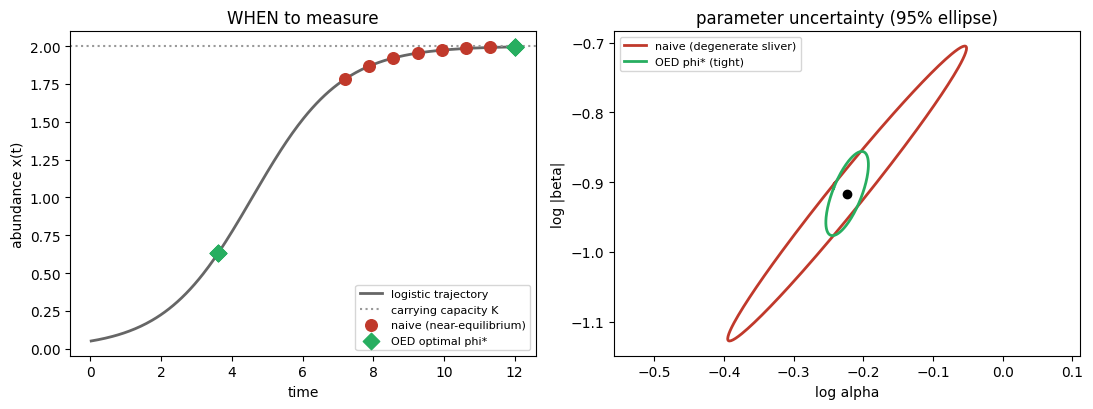

In [4]:
import jax.numpy as jnp

def abund_on(problem, ts):
    th = jnp.asarray(problem.theta0)
    return np.exp(np.asarray(problem.observe(th, jnp.asarray(ts)))) - 1e-2

fine = np.linspace(tmin, tmax, 300)
y_fine = abund_on(prob, fine)

def ellipse(fim, center, nsig=2.0):
    cov = np.linalg.inv(fim)
    vals, vecs = np.linalg.eigh(cov)
    t = np.linspace(0, 2 * np.pi, 200)
    circ = np.stack([np.cos(t), np.sin(t)])
    pts = vecs @ (np.sqrt(np.clip(vals, 0, None))[:, None] * circ) * nsig
    return center[0] + pts[0], center[1] + pts[1]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.plot(fine, y_fine, color="0.4", lw=2, label="logistic trajectory")
axL.axhline(prob.meta["K"], ls=":", color="0.6", label="carrying capacity K")
axL.scatter(naive, np.interp(naive, fine, y_fine), s=70, color="#c0392b",
            zorder=5, label="naive (near-equilibrium)")
axL.scatter(res.phi_opt, np.interp(res.phi_opt, fine, y_fine), s=70, marker="D",
            color="#27ae60", zorder=6, label="OED optimal phi*")
axL.set_xlabel("time"); axL.set_ylabel("abundance x(t)")
axL.set_title("WHEN to measure"); axL.legend(fontsize=8, loc="lower right")

center = prob.theta0
ex, ey = ellipse(res.fim_init, center)
ox, oy = ellipse(res.fim_opt, center)
axR.plot(ex, ey, color="#c0392b", lw=2, label="naive (degenerate sliver)")
axR.plot(ox, oy, color="#27ae60", lw=2, label="OED phi* (tight)")
axR.scatter([center[0]], [center[1]], color="k", zorder=5)
axR.set_xlabel("log alpha"); axR.set_ylabel("log |beta|")
axR.set_title("parameter uncertainty (95% ellipse)"); axR.legend(fontsize=8)
axR.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

## 3 · White-box gradient vs black-box grid search (honest)

On a **1-D design knob** (5 samples fixed at equilibrium, one free transient time `t1`) a
black box *can* afford a fine grid. We show the criterion landscape a grid would scan, and
that the **gradient locates the same peak** (its derivative crosses zero exactly there) —
deterministically, without the scan. The moat is the **scaling**: guaranteeing the optimum
over `m` free times by grid costs `rᵐ` evaluations.

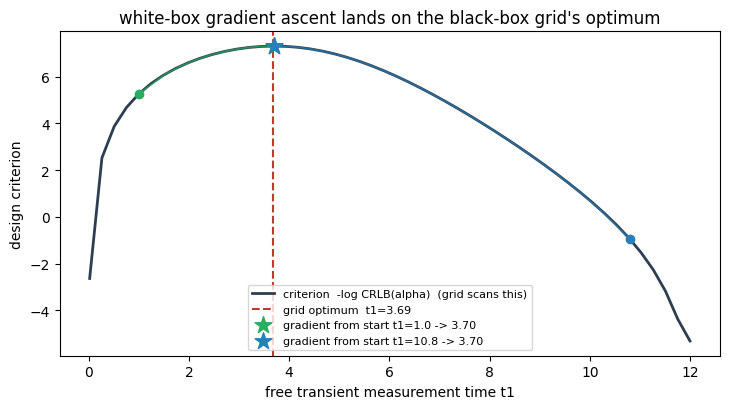

grid optimum t1 = 3.687   |   gradient endpoints: 3.701 (from 1.0), 3.700 (from 10.8)

Cost to GUARANTEE the optimum over m free times (structured grid, r^m FIM evals):
  m= 4:  4^m =             256    6^m =              1,296
  m= 8:  4^m =          65,536    6^m =          1,679,616
  m=16:  4^m =   4,294,967,296    6^m =  2,821,109,907,456
  -> the gradient optimizes all m times jointly in ~400 cheap steps. That is the moat.


In [5]:
def design1d(t1):
    return np.array([t1] + [tmax] * 5)   # 5 samples fixed at equilibrium, t1 free

# (a) the criterion landscape a black-box grid would scan
ts = np.linspace(tmin, tmax, 50)
land = np.array([criterion_value(prob, design1d(t), objective="crlb", target="log_alpha")
                 for t in ts])
t_grid = ts[int(np.argmax(land))]

# (b) an actual 1-D white-box gradient ASCENT on t1 (no scanning) from two far-apart starts
def ascend1d(t0, steps=120, lr=0.25):
    t = float(t0)
    path = [t]
    for _ in range(steps):
        gt = design_gradient(prob, design1d(t), objective="crlb", target="log_alpha")[0]
        t = float(np.clip(t + lr * gt, tmin, tmax))
        path.append(t)
    return np.array(path)

pathA = ascend1d(1.0)
pathB = ascend1d(10.8)
tstarA, tstarB = pathA[-1], pathB[-1]

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(ts, land, color="#2c3e50", lw=2, label="criterion  -log CRLB(alpha)  (grid scans this)")
ax.axvline(t_grid, color="#c0392b", ls="--", label=f"grid optimum  t1={t_grid:.2f}")
for path, c, s in ((pathA, "#27ae60", "start t1=1.0"), (pathB, "#2980b9", "start t1=10.8")):
    ax.plot(path, np.interp(path, ts, land), color=c, lw=1.2, alpha=0.7)
    ax.scatter([path[0]], [np.interp(path[0], ts, land)], color=c, marker="o", zorder=5)
    ax.scatter([path[-1]], [np.interp(path[-1], ts, land)], color=c, marker="*", s=160,
               zorder=6, label=f"gradient from {s} -> {path[-1]:.2f}")
ax.set_xlabel("free transient measurement time t1"); ax.set_ylabel("design criterion")
ax.set_title("white-box gradient ascent lands on the black-box grid's optimum")
ax.legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()

print(f"grid optimum t1 = {t_grid:.3f}   |   gradient endpoints: "
      f"{tstarA:.3f} (from 1.0), {tstarB:.3f} (from 10.8)")
assert abs(tstarA - t_grid) < 0.4 and abs(tstarB - t_grid) < 0.4, \
    "the white-box gradient must locate the grid's optimum from either start"

print("\nCost to GUARANTEE the optimum over m free times (structured grid, r^m FIM evals):")
for mm in (4, 8, 16):
    print(f"  m={mm:2d}:  4^m = {4 ** mm:>15,}    6^m = {6 ** mm:>18,}")
print("  -> the gradient optimizes all m times jointly in ~400 cheap steps. That is the moat.")

## 4 · Every objective resolves it — and it generalizes to a gLV community

The gain is not an artifact of one criterion: **D-optimality** (`log det FIM`),
**E-optimality** (`λ_min(FIM)`) and the **targeted reciprocal-CRLB** all resolve the sloppy
parameter. And the same machinery applied to a 3-taxon **generalized Lotka–Volterra**
community resolves a target taxon's growth ⇄ self-interaction confound too.

  d_opt :  CRLB(alpha)  31.3x better,  min-eig  17.5x better


  e_opt :  CRLB(alpha)  30.3x better,  min-eig  18.2x better


  crlb  :  CRLB(alpha)  31.5x better,  min-eig  17.8x better



  gLV (3 taxa, K_t=1.06):  CRLB(alpha_t) 1.52 -> 0.00254  (600x better)


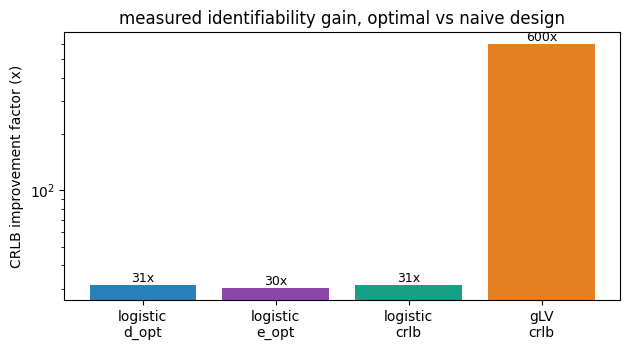

In [6]:
rows = []
for obj in ("d_opt", "e_opt", "crlb"):
    r = optimize_design(prob, naive, objective=obj, target="log_alpha",
                        steps=400, learning_rate=0.2)
    rows.append((obj, r.crlb_improvement, r.min_eig_improvement))
    print(f"  {obj:6s}:  CRLB(alpha) {r.crlb_improvement:5.1f}x better,  "
          f"min-eig {r.min_eig_improvement:5.1f}x better")

gprob = make_glv_design_problem(n_species=3, target=0)
gnaive = np.linspace(0.6 * gprob.phi_bounds[1], gprob.phi_bounds[1], 8)
gres = optimize_design(gprob, gnaive, objective="crlb", target="log_alpha_t",
                       steps=400, learning_rate=0.2)
print(f"\n  gLV (3 taxa, K_t={gprob.meta['K_t']:.2f}):  CRLB(alpha_t) "
      f"{gres.target_crlb_init:.3g} -> {gres.target_crlb_opt:.3g}  "
      f"({gres.crlb_improvement:.0f}x better)")
assert all(ci > 5 for _, ci, _ in rows), "all objectives must resolve the parameter"
assert gres.crlb_improvement > 10, "the gLV confound must resolve under the optimal design"

fig, ax = plt.subplots(figsize=(6.4, 3.6))
labels = [f"logistic\n{o}" for o, _, _ in rows] + ["gLV\ncrlb"]
vals = [ci for _, ci, _ in rows] + [gres.crlb_improvement]
ax.bar(labels, vals, color=["#2980b9", "#8e44ad", "#16a085", "#e67e22"])
ax.set_ylabel("CRLB improvement factor (x)"); ax.set_yscale("log")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.0f}x", ha="center", va="bottom", fontsize=9)
ax.set_title("measured identifiability gain, optimal vs naive design")
plt.tight_layout(); plt.show()

## What this buys — and the honest caveat

**Abstention → prescription.** NUDGE's gLV capability *abstains* when growth and
self-limitation are degenerate near equilibrium. OED turns that honest "cannot tell" into a
concrete experiment: *measure at these transient times and the parameter becomes
identifiable* — with the gain **measured** (here ~31× on the growth CRLB, ~600× for the gLV
community), never asserted.

**The caveat (`NUDGE-LIM-023`): this is LOCAL optimal design.** The Fisher information is
the local likelihood curvature at the nominal θ₀, so the optimal design and the reported
gains are valid *near* θ₀. A fully robust design would marginalize over a prior on θ; this
module does not. Near-singular FIMs are inverted with a guarded ridge (never a plain
pseudo-inverse, which would *understate* the CRLB — the opposite of safe), and the
grid-search baseline is shipped so a caller can *check* the gradient optimum.

**Reproduce it:**
```bash
nudge oed --model logistic --objective crlb      # the demo above, from the CLI
nudge oed --model glv --objective crlb           # the gLV community
```
`nudge.inference.oed` · Mechanism Card `NUDGE-METHOD-014` · findings in
`scripts/vv/FINDINGS.md` ("Optimal Experimental Design") · tests in
`tests/inference/test_oed.py`.
